In [ ]:

import os, json, time
from pathlib import Path
from tqdm import tqdm
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve,
                             precision_recall_fscore_support, accuracy_score,
                             matthews_corrcoef)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Paths
PROJECT_ROOT = Path("/Users/syedadnanahmad/Downloads/AI_TUMOUR_detection")  # change if needed
EMB_ROOT = PROJECT_ROOT / "embeddings"
IDX_CSV = PROJECT_ROOT / "notebooks" / "slide_index.csv"
MODEL_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# device
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Device:", device)


Device: mps


In [2]:
# Dataset that loads per-slide .npy embeddings
class SlideEmbDataset(Dataset):
    def __init__(self, index_df, split="train", class_map=None):
        """
        index_df: dataframe created earlier (slide_index.csv). Must have columns: split,class,slide_id
        split: 'train'/'val'/'test'
        class_map: dict mapping string class->int label (if None builds from unique classes in df)
        """
        self.split = split
        self.df = index_df[index_df["split"]==split].reset_index(drop=True)
        if class_map is None:
            classes = sorted(index_df["class"].unique())
            self.class_map = {c:i for i,c in enumerate(classes)}
        else:
            self.class_map = class_map
        self.items = []
        for _, r in self.df.iterrows():
            slide_id = r['slide_id']
            cls = r['class']
            emb_path = EMB_ROOT / split / cls / f"{slide_id}.npy"
            meta_path = EMB_ROOT / split / cls / f"{slide_id}_meta.json"
            if emb_path.exists():
                self.items.append({
                    "slide_id": slide_id,
                    "class": cls,
                    "label": self.class_map[cls],
                    "emb_path": str(emb_path),
                    "meta": str(meta_path)
                })
        # shuffle is handled externally in DataLoader
    def __len__(self):
        return len(self.items)
    def __getitem__(self, idx):
        it = self.items[idx]
        emb = np.load(it["emb_path"]).astype(np.float32)   # shape (n_patches, emb_dim)
        emb = torch.from_numpy(emb)                        # tensor (n_patches, emb_dim)
        label = torch.tensor(int(it["label"]), dtype=torch.long)
        return {"emb": emb, "label": label, "slide_id": it["slide_id"], "class": it["class"]}


In [3]:
#  Attention-based MIL model (gated attention) with optional Top-K pooling
class AttentionMIL(nn.Module):
    def __init__(self, emb_dim=512, hidden_dim=256, num_classes=2, topk=None):
        """
        emb_dim: input embedding dimension
        hidden_dim: attention internal dim
        num_classes: output classes
        topk: if int, after attention compute topk patches and average them; if None do weighted mean
        """
        super().__init__()
        self.emb_dim = emb_dim
        self.hidden_dim = hidden_dim
        self.topk = topk
        # Gated attention: V and U are learned transforms
        self.att_V = nn.Linear(emb_dim, hidden_dim)
        self.att_U = nn.Linear(emb_dim, hidden_dim)
        self.att_w = nn.Linear(hidden_dim, 1)  # produces unnormalized attention score

        # classifier on aggregated slide representation
        self.classifier = nn.Sequential(
            nn.Linear(emb_dim, emb_dim//2),
            nn.ReLU(inplace=True),
            nn.Dropout(0.25),
            nn.Linear(emb_dim//2, num_classes)
        )

    def att_forward(self, H):
        # H: (N, D)
        Vh = torch.tanh(self.att_V(H))        # (N, hidden)
        Uh = torch.sigmoid(self.att_U(H))     # (N, hidden)
        gated = Vh * Uh                       # (N, hidden)
        scores = self.att_w(gated).squeeze(-1)  # (N,)
        return scores

    def forward(self, H):
        """
        H: (N, D) tensor for one slide/bag
        returns logits (1, num_classes), attention_weights (N,)
        """
        scores = self.att_forward(H)  # (N,)
        attn = torch.softmax(scores, dim=0)  # normalized (N,)

        if self.topk is not None and self.topk > 0 and H.shape[0] > self.topk:
            # pick top-k by attention score (before softmax for deterministic selection)
            topk_vals, topk_idx = torch.topk(scores, self.topk, largest=True)
            H_topk = H[topk_idx]  # (topk, D)
            agg = H_topk.mean(dim=0)  # (D,)
            # recalc attention weights for topk (optional) - we return original attn (full)
        else:
            # weighted mean by attention
            agg = torch.sum(attn.unsqueeze(-1) * H, dim=0)  # (D,)

        logits = self.classifier(agg)  # (num_classes,)
        return logits.unsqueeze(0), attn  # logits shape (1, C), attn (N,)


In [4]:
#  helpers

def collate_fn(batch):
    # batch is list of dicts (we will use batch_size=1 for DataLoader)
    return batch[0]

# metrics helper (multiclass)
from sklearn.preprocessing import label_binarize

def compute_metrics_all(y_true, y_pred, y_score, class_names):
    """
    y_true: list/array ints
    y_pred: predicted ints
    y_score: numpy array shape (n, C) with softmax probabilities
    """
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(y_true, y_pred, average=None, labels=range(len(class_names)))
    macro_f1 = precision_recall_fscore_support(y_true, y_pred, average='macro')[2]
    # ROC AUC (one-vs-rest) for multiclass
    y_true_bin = label_binarize(y_true, classes=range(len(class_names)))
    try:
        roc_auc = roc_auc_score(y_true_bin, y_score, average='macro', multi_class='ovr')
    except Exception as e:
        roc_auc = None
    cm = confusion_matrix(y_true, y_pred, labels=range(len(class_names)))
    metrics = {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "per_class_precision": prec,
        "per_class_recall": rec,
        "per_class_f1": f1,
        "roc_auc": roc_auc,
        "confusion_matrix": cm
    }
    return metrics


In [5]:
#  prepare datasets and model (quick defaults)
idx_df = pd.read_csv(IDX_CSV)
# consistent class_map from train split order
classes = sorted(idx_df["class"].unique())
class_map = {c:i for i,c in enumerate(classes)}
print("Classes:", classes)
num_classes = len(classes)  # 5 in ORCHID (wdoscc, mdoscc, osmf, pdoscc, normal)

train_ds = SlideEmbDataset(idx_df, split="train", class_map=class_map)
val_ds   = SlideEmbDataset(idx_df, split="val", class_map=class_map)
test_ds  = SlideEmbDataset(idx_df, split="test", class_map=class_map)

print("train slides:", len(train_ds), "val slides:", len(val_ds), "test slides:", len(test_ds))

# dataloaders - batch_size=1 (one bag per step)
train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, collate_fn=collate_fn, num_workers=0)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, collate_fn=collate_fn, num_workers=0)

# model
EMB_DIM = 512
model = AttentionMIL(emb_dim=EMB_DIM, hidden_dim=256, num_classes=num_classes, topk=None)  # start with attention pooling
model.to(device)

# optimizer & loss
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.CrossEntropyLoss()


Classes: ['mdoscc', 'normal', 'osmf', 'pdoscc', 'wdoscc']
train slides: 149 val slides: 149 test slides: 150


In [6]:
# Cell 6: train & validate functions

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    losses = []
    y_true, y_pred, y_score = [], [], []
    for batch in tqdm(loader, desc="Train"):
        emb = batch["emb"].to(device)  # (N,D)
        label = batch["label"].to(device)
        optimizer.zero_grad()
        logits, attn = model(emb)     # logits (1,C)
        loss = criterion(logits, label.unsqueeze(0))
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

        probs = F.softmax(logits, dim=1).detach().cpu().numpy()[0]
        pred = int(probs.argmax())
        y_true.append(int(label.cpu().numpy()))
        y_pred.append(pred)
        y_score.append(probs)
    avg_loss = np.mean(losses)
    return avg_loss, np.array(y_true), np.array(y_pred), np.vstack(y_score)

def validate(model, loader, criterion, device):
    model.eval()
    losses = []
    y_true, y_pred, y_score = [], [], []
    with torch.no_grad():
        for batch in tqdm(loader, desc="Val"):
            emb = batch["emb"].to(device)
            label = batch["label"].to(device)
            logits, attn = model(emb)
            loss = criterion(logits, label.unsqueeze(0))
            losses.append(loss.item())
            probs = F.softmax(logits, dim=1).cpu().numpy()[0]
            pred = int(probs.argmax())
            y_true.append(int(label.cpu().numpy()))
            y_pred.append(pred)
            y_score.append(probs)
    avg_loss = np.mean(losses)
    return avg_loss, np.array(y_true), np.array(y_pred), np.vstack(y_score)

# quick smoke-run: one epoch
start = time.time()
train_loss, tr_y, tr_pred, tr_score = train_one_epoch(model, train_loader, optimizer, criterion, device)
val_loss, va_y, va_pred, va_score = validate(model, val_loader, criterion, device)
print("Train loss:", train_loss, "Val loss:", val_loss)
print("Train acc:", accuracy_score(tr_y, tr_pred), "Val acc:", accuracy_score(va_y, va_pred))
print("Train macro F1:", precision_recall_fscore_support(tr_y, tr_pred, average='macro')[2],
      "Val macro F1:", precision_recall_fscore_support(va_y, va_pred, average='macro')[2])
print("Elapsed:", (time.time()-start)/60, "minutes")


Val: 100%|██████████| 149/149 [00:01<00:00, 116.33it/s]

Train loss: 1.5691139265994898 Val loss: 1.520203004747429
Train acc: 0.2550335570469799 Val acc: 0.3624161073825503
Train macro F1: 0.1479229342927662 Val macro F1: 0.18247540608556395
Elapsed: 0.11431766351064046 minutes



/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/oral_msc/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [7]:
# A: compute class weights from train labels and update criterion
from collections import Counter
train_labels = [item["label"] for item in train_ds.items]  # ints
counts = Counter(train_labels)
print("Train label counts:", counts)
num_classes = len(classes)
# weight = total / (num_classes * count)
total = sum(counts.values())
class_weights = [ total / (num_classes * counts.get(i,1)) for i in range(num_classes) ]
class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
print("Class weights:", class_weights)

# update loss to use weights
criterion = nn.CrossEntropyLoss(weight=class_weights)


Train label counts: Counter({4: 44, 0: 41, 2: 31, 3: 19, 1: 14})
Class weights: tensor([0.7268, 2.1286, 0.9613, 1.5684, 0.6773], device='mps:0')


In [9]:
# B: train full loop with checkpointing, scheduler, early stopping
import copy
from sklearn.metrics import precision_recall_fscore_support

EPOCHS = 20
best_macro_f1 = -1.0
best_ckpt = MODEL_DIR / "mil_best.pth"
patience = 5
no_improve = 0

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=2)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    train_loss, tr_y, tr_pred, tr_score = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, va_y, va_pred, va_score = validate(model, val_loader, criterion, device)

    # metrics robustly (zero_division=0)
    tr_prec, tr_rec, tr_f1, _ = precision_recall_fscore_support(tr_y, tr_pred, labels=list(range(num_classes)), zero_division=0)
    va_prec, va_rec, va_f1, _ = precision_recall_fscore_support(va_y, va_pred, labels=list(range(num_classes)), zero_division=0)
    va_macro_f1 = np.mean(va_f1)

    print(f"\nEpoch {epoch}/{EPOCHS}  time={(time.time()-t0)/60:.2f} min")
    print(f"Train loss: {train_loss:.4f}  Val loss: {val_loss:.4f}")
    print(f"Train acc: {accuracy_score(tr_y, tr_pred):.4f}  Val acc: {accuracy_score(va_y, va_pred):.4f}")
    print(f"Train macro F1: {np.mean(tr_f1):.4f}  Val macro F1: {va_macro_f1:.4f}")
    print("Val per-class F1:", {classes[i]: float(va_f1[i]) for i in range(num_classes)})

    # scheduler step (monitor validation macro_f1)
    scheduler.step(va_macro_f1)

    # checkpoint if improved
    if va_macro_f1 > best_macro_f1:
        best_macro_f1 = va_macro_f1
        no_improve = 0
        torch.save({
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "class_map": class_map,
            "epoch": epoch,
            "val_macro_f1": best_macro_f1
        }, best_ckpt)
        print("Saved new best checkpoint:", best_ckpt)
    else:
        no_improve += 1
        print(f"No improvement ({no_improve}/{patience})")

    # early stopping
    if no_improve >= patience:
        print("Early stopping triggered.")
        break


Val: 100%|██████████| 149/149 [00:00<00:00, 418.86it/s]



Epoch 1/20  time=0.03 min
Train loss: 1.5067  Val loss: 1.4798
Train acc: 0.2953  Val acc: 0.3758
Train macro F1: 0.1477  Val macro F1: 0.1901
Val per-class F1: {'mdoscc': 0.41818181818181815, 'normal': 0.0, 'osmf': 0.0, 'pdoscc': 0.0, 'wdoscc': 0.532258064516129}
Saved new best checkpoint: /Users/syedadnanahmad/Downloads/AI_TUMOUR_detection/models/mil_best.pth


Val: 100%|██████████| 149/149 [00:00<00:00, 400.51it/s]



Epoch 2/20  time=0.02 min
Train loss: 1.4751  Val loss: 1.4465
Train acc: 0.3289  Val acc: 0.3826
Train macro F1: 0.1825  Val macro F1: 0.2104
Val per-class F1: {'mdoscc': 0.3883495145631068, 'normal': 0.0, 'osmf': 0.12121212121212122, 'pdoscc': 0.0, 'wdoscc': 0.5426356589147286}
Saved new best checkpoint: /Users/syedadnanahmad/Downloads/AI_TUMOUR_detection/models/mil_best.pth


Val: 100%|██████████| 149/149 [00:00<00:00, 391.87it/s]


...


Epoch 17/20  time=0.02 min
Train loss: 0.8233  Val loss: 0.9562
Train acc: 0.7047  Val acc: 0.6107
Train macro F1: 0.7186  Val macro F1: 0.5958
Val per-class F1: {'mdoscc': 0.5517241379310345, 'normal': 0.6, 'osmf': 0.7142857142857143, 'pdoscc': 0.4827586206896552, 'wdoscc': 0.6304347826086957}
No improvement (3/5)


Val: 100%|██████████| 149/149 [00:00<00:00, 462.73it/s]



Epoch 18/20  time=0.02 min
Train loss: 0.7801  Val loss: 0.9453
Train acc: 0.7181  Val acc: 0.6107
Train macro F1: 0.7256  Val macro F1: 0.6043
Val per-class F1: {'mdoscc': 0.5517241379310345, 'normal': 0.6666666666666666, 'osmf': 0.7058823529411765, 'pdoscc': 0.4666666666666667, 'wdoscc': 0.6304347826086957}
No improvement (4/5)


Val: 100%|██████████| 149/149 [00:00<00:00, 466.05it/s]


Epoch 19/20  time=0.02 min
Train loss: 0.7544  Val loss: 0.9381
Train acc: 0.7517  Val acc: 0.6242
Train macro F1: 0.7643  Val macro F1: 0.6188
Val per-class F1: {'mdoscc': 0.5494505494505495, 'normal': 0.6666666666666666, 'osmf': 0.75, 'pdoscc': 0.4827586206896552, 'wdoscc': 0.6451612903225806}
No improvement (5/5)
Early stopping triggered.


In [12]:
# Cell 7: example checkpoint save
ckpt = MODEL_DIR / "mil_initial.pth"
torch.save({
    "model_state": model.state_dict(),
    "optimizer_state": optimizer.state_dict(),
    "class_map": class_map
}, ckpt)
print("Saved checkpoint to", ckpt)


Saved checkpoint to /Users/syedadnanahmad/Downloads/AI_TUMOUR_detection/models/mil_initial.pth


In [13]:
# Run this cell, then re-run Cell C
import matplotlib.pyplot as plt
import seaborn as sns

def plot_confusion(cm, classes, normalize=True, cmap="Blues", size=(6,5), savepath=None):
    if normalize:
        cmn = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    else:
        cmn = cm
    plt.figure(figsize=size)
    sns.heatmap(cmn, annot=True, fmt=".2f" if normalize else "d", cmap=cmap,
                xticklabels=classes, yticklabels=classes)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion matrix" + (" (normalized)" if normalize else ""))
    if savepath:
        plt.savefig(savepath, bbox_inches="tight")
    plt.show()


Loading checkpoint: /Users/syedadnanahmad/Downloads/AI_TUMOUR_detection/models/mil_best.pth
Normal load failed, retrying with weights_only=False ...


Val: 100%|██████████| 150/150 [00:00<00:00, 448.43it/s]



Test Loss: 1.0352721651395163
=== Test Classification Report ===
              precision    recall  f1-score   support

      mdoscc       0.50      0.67      0.57        42
      normal       0.88      0.50      0.64        14
        osmf       0.79      0.71      0.75        31
      pdoscc       0.67      0.32      0.43        19
      wdoscc       0.55      0.61      0.58        44

    accuracy                           0.60       150
   macro avg       0.68      0.56      0.59       150
weighted avg       0.63      0.60      0.60       150

Confusion Matrix:
 [[28  0  0  2 12]
 [ 3  7  3  0  1]
 [ 1  1 22  0  7]
 [10  0  1  6  2]
 [14  0  2  1 27]]


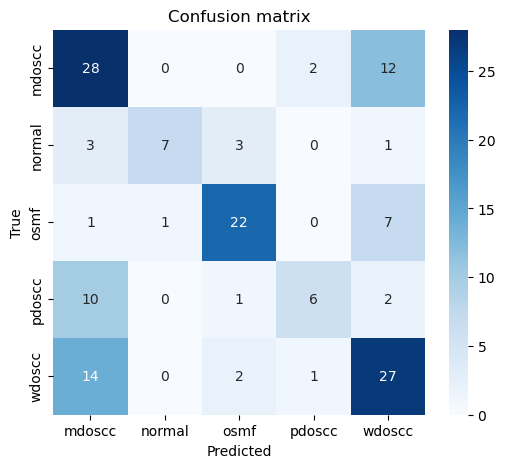

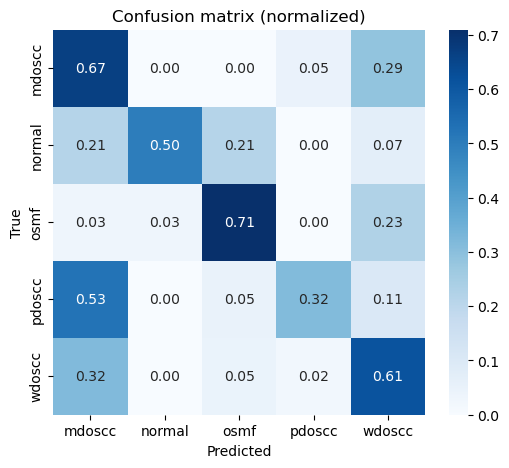

Test ROC AUC (macro): 0.8692573827061757

Saved confusion matrices to: /Users/syedadnanahmad/Downloads/AI_TUMOUR_detection/results


In [14]:
# ============================
# Cell C — Load best model and evaluate on test set
# ============================

import torch
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import label_binarize

# Load best checkpoint safely (handles PyTorch 2.6+ changes)
ckpt_path = best_ckpt
print("Loading checkpoint:", ckpt_path)

try:
    # Try normal load first
    ck = torch.load(ckpt_path, map_location=device)
except Exception as e:
    print("Normal load failed, retrying with weights_only=False ...")
    try:
        ck = torch.load(ckpt_path, map_location=device, weights_only=False)
    except Exception as e2:
        print("Failed again. Trying CPU load with weights_only=False ...")
        ck = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# Load model weights
model.load_state_dict(ck["model_state"])
model.to(device)
model.eval()

# ============================
# Test evaluation
# ============================

test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, collate_fn=collate_fn, num_workers=0)
test_loss, te_y, te_pred, te_score = validate(model, test_loader, criterion, device)

print("\nTest Loss:", test_loss)

# Classification report
report = classification_report(te_y, te_pred, target_names=classes, zero_division=0)
print("=== Test Classification Report ===")
print(report)

# ============================
# Confusion Matrix (raw + normalized)
# ============================
cm = confusion_matrix(te_y, te_pred, labels=list(range(num_classes)))
print("Confusion Matrix:\n", cm)

plot_confusion(cm, classes, normalize=False, savepath=RESULTS_DIR/"confusion_test_raw.png")
plot_confusion(cm, classes, normalize=True, savepath=RESULTS_DIR/"confusion_test_norm.png")

# ============================
# ROC AUC (Multiclass)
# ============================
try:
    te_y_bin = label_binarize(te_y, classes=list(range(num_classes)))
    roc_auc = roc_auc_score(te_y_bin, te_score, average='macro', multi_class='ovr')
    print("Test ROC AUC (macro):", roc_auc)
except Exception as e:
    print("ROC AUC couldn't be computed:", e)

print("\nSaved confusion matrices to:", RESULTS_DIR)
